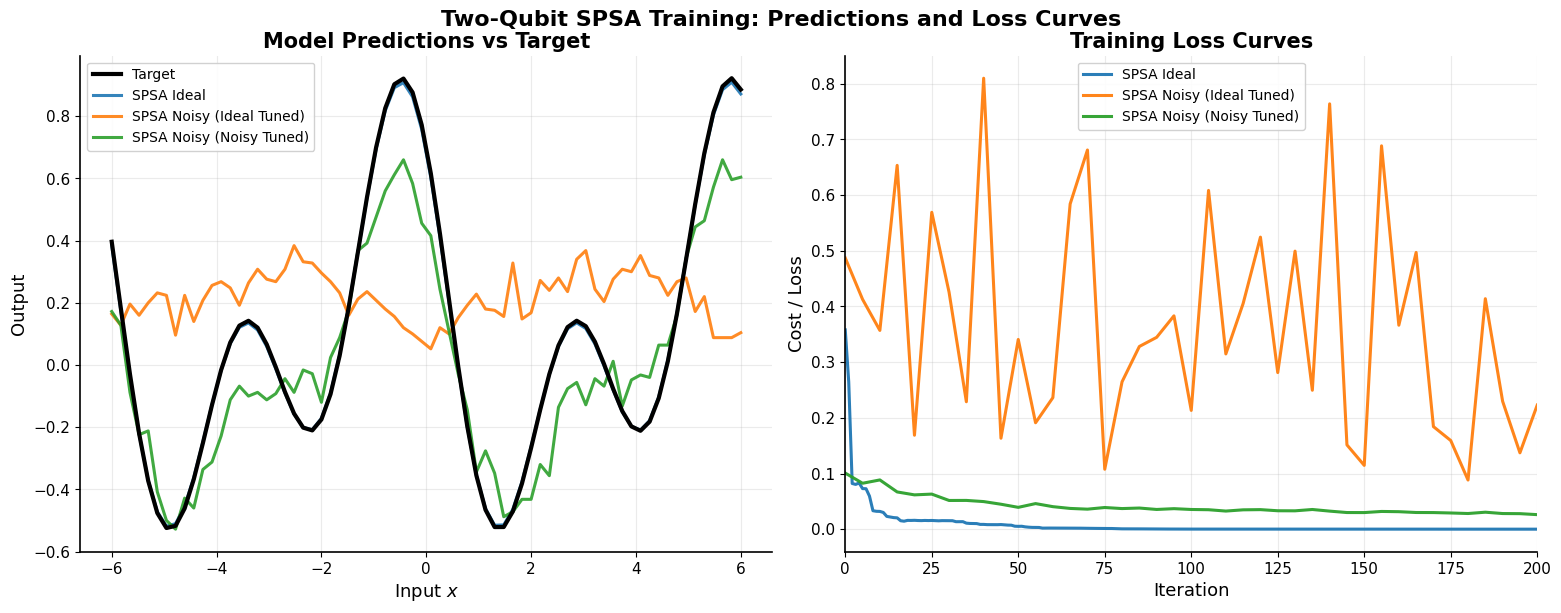

Saved publication-quality PDF as: spsa_predictions_and_losses_2_qubit.pdf


In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt

# =========================
# PLOT STYLE
# =========================
plt.rcParams.update({
    "font.size": 12,
    "axes.titlesize": 15,
    "axes.labelsize": 13,
    "legend.fontsize": 10,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "figure.titlesize": 16,
    "axes.linewidth": 1.2,
    "lines.linewidth": 2.2,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

# =========================
# FILE PATHS
# =========================
target_file = "target_2_qubit.npy"
input_file = "input_2_qubit.npy"

pred_files = {
    "SPSA Ideal": "pred_spsa_ideal_2_qubit.npy",
    "SPSA Noisy (Ideal Tuned)": "pred_spsa_noisy_2_qubit.npy(ideal tuned).npy",
    "SPSA Noisy (Noisy Tuned)": "pred_spsa_noisy_2_qubit.npy(noisy tuned).npy",
}

cost_files = {
    "SPSA Ideal": "cost_spsa_ideal_2_qubit.npy",
    "SPSA Noisy (Ideal Tuned)": "cost_spsa_noisy_2_qubit(ideal tuned).npy",
    "SPSA Noisy (Noisy Tuned)": "cost_spsa_noisy_2_qubit(noisy tuned).npy",
}

record_every = {
    "SPSA Ideal": 1,
    "SPSA Noisy (Ideal Tuned)": 5,
    "SPSA Noisy (Noisy Tuned)": 5,
}

output_pdf = "spsa_predictions_and_losses_2_qubit.pdf"


# =========================
# HELPER FUNCTIONS
# =========================
def load_npy_1d(file_path):
    if not os.path.exists(file_path):
        raise FileNotFoundError(f"File not found: {file_path}")

    arr = np.load(file_path, allow_pickle=True)
    return np.asarray(arr).squeeze().reshape(-1)


def check_same_length(name, arr, reference, reference_name):
    if len(arr) != len(reference):
        raise ValueError(
            f"{name} has length {len(arr)}, but {reference_name} has length {len(reference)}."
        )


# =========================
# LOAD DATA
# =========================
X = load_npy_1d(input_file)
y_true = load_npy_1d(target_file)

check_same_length("Input X", X, y_true, "target y")

pred_data = {}
for label, file in pred_files.items():
    pred = load_npy_1d(file)
    check_same_length(f"{label} prediction", pred, y_true, "target y")
    pred_data[label] = pred

cost_data = {}
for label, file in cost_files.items():
    cost_data[label] = load_npy_1d(file)


# =========================
# FIX COLORS ACROSS BOTH SUBPLOTS
# =========================
label_colors = {
    label: f"C{i}"
    for i, label in enumerate(pred_files.keys())
}


# =========================
# SORT BY INPUT X
# =========================
sort_idx = np.argsort(X)

X_sorted = X[sort_idx]
y_true_sorted = y_true[sort_idx]

pred_data_sorted = {
    label: pred[sort_idx]
    for label, pred in pred_data.items()
}


# =========================
# CREATE SIDE-BY-SIDE SUBPLOTS
# =========================
fig, axes = plt.subplots(
    1,
    2,
    figsize=(15.5, 5.8),
    constrained_layout=True
)

fig.suptitle(
    "Two-Qubit SPSA Training: Predictions and Loss Curves",
    fontweight="bold",
    y=1.03
)

# =========================
# Subplot 1: Predictions vs Target
# =========================
ax = axes[0]

ax.plot(
    X_sorted,
    y_true_sorted,
    label="Target",
    linewidth=3.0,
    linestyle="-",
    zorder=5,
    color="black"
)

for label, y_pred_sorted in pred_data_sorted.items():
    ax.plot(
        X_sorted,
        y_pred_sorted,
        label=label,
        linewidth=2.2,
        alpha=0.9,
        color=label_colors[label]
    )

ax.set_title("Model Predictions vs Target", fontweight="bold")
ax.set_xlabel("Input $x$")
ax.set_ylabel("Output")
ax.grid(True, alpha=0.25, linewidth=0.8)
ax.legend(frameon=True, fancybox=True, framealpha=0.9)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)


# =========================
# Subplot 2: Loss Curves
# =========================
ax = axes[1]

for label, cst in cost_data.items():
    step = record_every[label]
    iterations = np.arange(len(cst)) * step

    ax.plot(
        iterations,
        cst,
        label=label,
        linewidth=2.2,
        alpha=0.95,
        color=label_colors[label]
    )

ax.set_title("Training Loss Curves", fontweight="bold")
ax.set_xlabel("Iteration")
ax.set_ylabel("Cost / Loss")
ax.set_xlim(0, 200)
ax.grid(True, alpha=0.25, linewidth=0.8)
ax.legend(frameon=True, fancybox=True, framealpha=0.9)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)


# =========================
# SAVE AS ONE PDF
# =========================
plt.savefig(output_pdf, format="pdf", bbox_inches="tight", dpi=300)
plt.show()

print(f"Saved publication-quality PDF as: {output_pdf}")

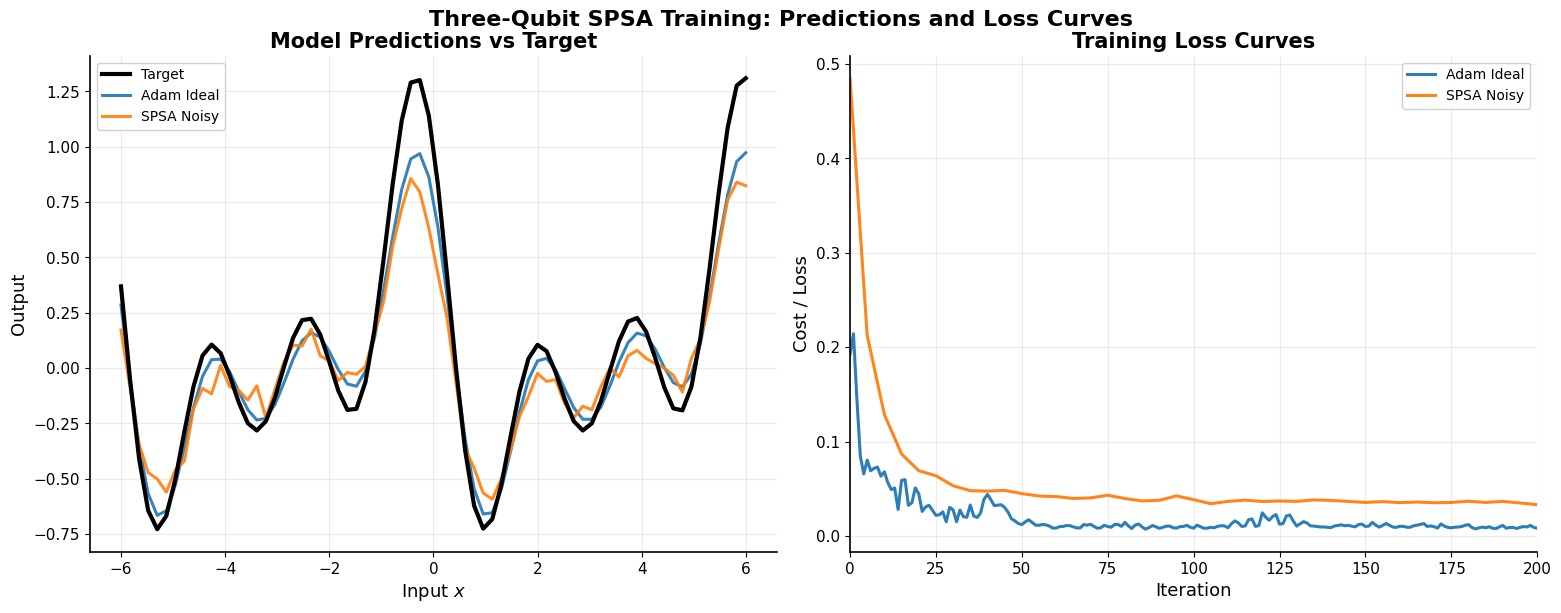

Saved publication-quality PDF as: spsa_predictions_and_losses_3_qubit.pdf


In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt

# =========================
# PLOT STYLE
# =========================
plt.rcParams.update({
    "font.size": 12,
    "axes.titlesize": 15,
    "axes.labelsize": 13,
    "legend.fontsize": 10,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "figure.titlesize": 16,
    "axes.linewidth": 1.2,
    "lines.linewidth": 2.2,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

# =========================
# FILE PATHS
# =========================
target_file = "target_3_qubit.npy"
input_file = "input_2_qubit.npy"

pred_files = {
    "Adam Ideal": "pred_Adam_ideal_3_qubit.npy",
    "SPSA Noisy": "pred_spsa_noisy_3_qubit.npy",
    
}

cost_files = {
    "Adam Ideal": "cost_Adam_ideal_3_qubit.npy",
    "SPSA Noisy": "cost_spsa_noisy_3_qubit.npy",
    
}

record_every = {
    "Adam Ideal": 1,
    "SPSA Noisy": 5,
    
}

output_pdf = "spsa_predictions_and_losses_3_qubit.pdf"


# =========================
# HELPER FUNCTIONS
# =========================
def load_npy_1d(file_path):
    if not os.path.exists(file_path):
        raise FileNotFoundError(f"File not found: {file_path}")

    arr = np.load(file_path, allow_pickle=True)
    return np.asarray(arr).squeeze().reshape(-1)


def check_same_length(name, arr, reference, reference_name):
    if len(arr) != len(reference):
        raise ValueError(
            f"{name} has length {len(arr)}, but {reference_name} has length {len(reference)}."
        )


# =========================
# LOAD DATA
# =========================
X = load_npy_1d(input_file)
y_true = load_npy_1d(target_file)

check_same_length("Input X", X, y_true, "target y")

pred_data = {}
for label, file in pred_files.items():
    pred = load_npy_1d(file)
    check_same_length(f"{label} prediction", pred, y_true, "target y")
    pred_data[label] = pred

cost_data = {}
for label, file in cost_files.items():
    cost_data[label] = load_npy_1d(file)


# =========================
# FIX COLORS ACROSS BOTH SUBPLOTS
# =========================
label_colors = {
    label: f"C{i}"
    for i, label in enumerate(pred_files.keys())
}


# =========================
# SORT BY INPUT X
# =========================
sort_idx = np.argsort(X)

X_sorted = X[sort_idx]
y_true_sorted = y_true[sort_idx]

pred_data_sorted = {
    label: pred[sort_idx]
    for label, pred in pred_data.items()
}


# =========================
# CREATE SIDE-BY-SIDE SUBPLOTS
# =========================
fig, axes = plt.subplots(
    1,
    2,
    figsize=(15.5, 5.8),
    constrained_layout=True
)

fig.suptitle(
    "Three-Qubit SPSA Training: Predictions and Loss Curves",
    fontweight="bold",
    y=1.03
)

# =========================
# Subplot 1: Predictions vs Target
# =========================
ax = axes[0]

ax.plot(
    X_sorted,
    y_true_sorted,
    label="Target",
    linewidth=3.0,
    linestyle="-",
    zorder=5,
    color="black"
)

for label, y_pred_sorted in pred_data_sorted.items():
    ax.plot(
        X_sorted,
        y_pred_sorted,
        label=label,
        linewidth=2.2,
        alpha=0.9,
        color=label_colors[label]
    )

ax.set_title("Model Predictions vs Target", fontweight="bold")
ax.set_xlabel("Input $x$")
ax.set_ylabel("Output")
ax.grid(True, alpha=0.25, linewidth=0.8)
ax.legend(frameon=True, fancybox=True, framealpha=0.9)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)


# =========================
# Subplot 2: Loss Curves
# =========================
ax = axes[1]

for label, cst in cost_data.items():
    step = record_every[label]
    iterations = np.arange(len(cst)) * step

    ax.plot(
        iterations,
        cst,
        label=label,
        linewidth=2.2,
        alpha=0.95,
        color=label_colors[label]
    )

ax.set_title("Training Loss Curves", fontweight="bold")
ax.set_xlabel("Iteration")
ax.set_ylabel("Cost / Loss")
ax.set_xlim(0, 200)
ax.grid(True, alpha=0.25, linewidth=0.8)
ax.legend(frameon=True, fancybox=True, framealpha=0.9)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)


# =========================
# SAVE AS ONE PDF
# =========================
plt.savefig(output_pdf, format="pdf", bbox_inches="tight", dpi=300)
plt.show()

print(f"Saved publication-quality PDF as: {output_pdf}")